In [1]:
import os

import bids
from bids import BIDSLayout
import nibabel as nb
import warnings

import pandas as pd
import numpy as np
import json
import gzip

from nilearn import image as nimg
from nilearn import plotting as nplot

import seaborn as sns
import ptitprince as pt
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from scipy import stats

sns.set_theme(style='whitegrid', palette='bright', color_codes=True)
warnings.filterwarnings('ignore')
%matplotlib inline

Websites accessed:
1. https://github.com/nipy/workshops/blob/master/170327-nipype/notebooks/basic-bids/basic_data_input_bids.ipynb
2. https://carpentries-incubator.github.io/SDC-BIDS-fMRI/aio/index.html

FMRI analysis course:
https://carpentries-incubator.github.io/SDC-BIDS-fMRI/01-intro-and-preprocessing/index.html

## 1.1 Basic Checks

Just checking whether the dataset is properly downloaded and files are loading

In [2]:
data_path = "openpain.org/subacute_longitudinal_study/"
layout = BIDSLayout(data_path)
print(layout)

BIDS Layout: ...rg/subacute_longitudinal_study | Subjects: 122 | Sessions: 496 | Runs: 176


In [3]:
layout.get_subjects()

['014',
 '095',
 '038',
 '013',
 '084',
 '072',
 '036',
 '118',
 '049',
 '066',
 '073',
 '047',
 '101',
 '087',
 '119',
 '103',
 '020',
 '088',
 '028',
 '059',
 '007',
 '081',
 '006',
 '060',
 '074',
 '043',
 '044',
 '004',
 '061',
 '108',
 '078',
 '016',
 '056',
 '008',
 '109',
 '054',
 '029',
 '110',
 '055',
 '064',
 '040',
 '003',
 '032',
 '001',
 '104',
 '063',
 '105',
 '012',
 '009',
 '010',
 '046',
 '077',
 '112',
 '106',
 '026',
 '122',
 '062',
 '042',
 '097',
 '031',
 '076',
 '037',
 '091',
 '022',
 '002',
 '065',
 '019',
 '071',
 '069',
 '027',
 '099',
 '070',
 '024',
 '041',
 '075',
 '017',
 '085',
 '023',
 '115',
 '057',
 '080',
 '086',
 '117',
 '068',
 '018',
 '039',
 '015',
 '067',
 '034',
 '052',
 '093',
 '111',
 '102',
 '100',
 '083',
 '053',
 '011',
 '050',
 '033',
 '120',
 '096',
 '098',
 '092',
 '094',
 '107',
 '035',
 '116',
 '025',
 '021',
 '005',
 '051',
 '058',
 '030',
 '045',
 '082',
 '114',
 '090',
 '079',
 '121',
 '089',
 '048',
 '113']

In [4]:
layout.get_tr()

2.5

In [5]:
layout.get_dataset_description()

{'BIDSVersion': '1.0.0',
 'Name': 'Longitudinal subacute back pain study',
 'License': 'Open Data Commons PDD License',
 'Authors': ['Apkarian AV',
  'Baliki MN',
  'Baria AT',
  'Berger SE',
  'Hashmi JA',
  'Hermann KM',
  'Mansour A',
  'Parks E',
  'Petre B',
  'Schnitzer T',
  'Torbey S'],
 'HowToAcknowledge': 'If using this dataset, please cite Vachon-Presseau E, et al (2016). Corticolimbic anatomical characteristics predetermin risk for chronic pain. Brain (139), 1958-1970.',
 'Funding': 'National Institute of Neurological Disorders and Stroke (NS035115)',
 'ReferencesAndLinks': ['Baliki MN, Petre B, Torbey S, Hermann KM, Huang L, Schnitzer TJ, Fields HL, Apkarian AV (2012). Corticostriatal functional connectivity predicts transition to chronic back pain. Nat Neurosci (15), 1117-9.',
  'Hashmi JA, Baliki MN, Huang L, Baria AT, Torbey S, Hermann KM, Schnitzer TJ, Apkarian AV (2013). Shape shifting pain: chronification of back pain shifts brain representation from nociceptive to e

In [6]:
layout.get_tasks()

['resting', 'sp', 'sv', 'mv']

### Doubt

What do these tasks mean?

In [7]:
layout.get(subject='001')

[<BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/anat/sub-001_ses-visit1_T1w.nii.gz'>,
 <BIDSFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/dwi/sub-001_ses-visit1_dwi.bval'>,
 <BIDSFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/dwi/sub-001_ses-visit1_dwi.bvec'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/dwi/sub-001_ses-visit1_dwi.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/func/sub-001_ses-visit1_task-mv_bold.nii.gz'>,
 <BIDSDataFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/func/sub-001_ses-visit1_task-mv_stim.tsv.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp

In [8]:
layout.get(subject='104', extension=['nii', 'nii.gz'])

[<BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/anat/sub-104_ses-visit1_T1w.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/dwi/sub-104_ses-visit1_dwi.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/func/sub-104_ses-visit1_task-mv_bold.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/func/sub-104_ses-visit1_task-sp_run-01_bold.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/func/sub-104_ses-visit1_task-sp_run-02_bold.nii.gz'>,
 <BIDSImageFile filename='/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-104/ses-visit1/func/sub-104_ses-visit1_task-sv_bold.nii.gz'>]

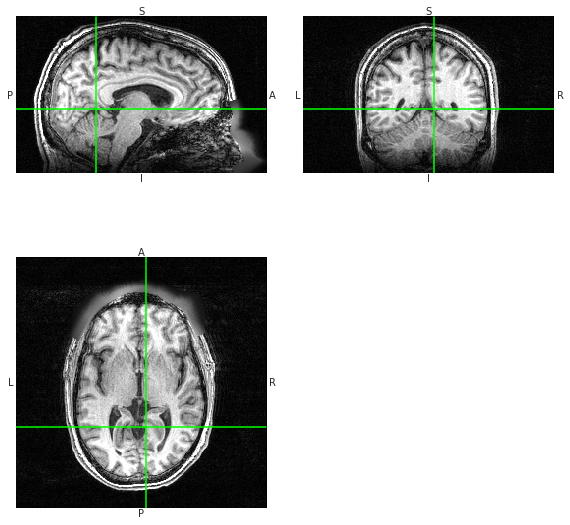

In [9]:
def plot_nii(in_file):
    nii = nb.load(in_file)
    nii.orthoview()

plot_nii(data_path + "sub-104/ses-visit1/anat/sub-104_ses-visit1_T1w.nii.gz")

In [10]:
img = nb.load(data_path + "sub-104/ses-visit1/anat/sub-104_ses-visit1_T1w.nii.gz")
print(img)

<class 'nibabel.nifti1.Nifti1Image'>
data shape (256, 256, 160)
affine: 
[[ -1.   0.   0. 123.]
 [  0.   1.   0. -82.]
 [  0.   0.   1. -66.]
 [  0.   0.   0.   1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 256 256 160   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.   1.   1.   1.   2.3  0.   0.   0. ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL5.0'
aux_file        : b''
qform_code      : aligned
sform_code     

## 1.2 Loading the data collected on participants of the study

In [11]:
participants_df = pd.read_csv('openpain.org/subacute_longitudinal_study/participants.tsv', sep='\t')
participants_df

,participant_id,group,race,gender,age,years_education,$bracket,approximate_duration_in_weeks,origin,rs2239393,...,rs1042713,rs1799971,rs569356,rs678849,rs6090453,rs4334545,rs324419,rs2295633,rs6265,rs16147
0,sub-001,subacute,6,M,27,16.0,3.0,15.0,4,AG,...,AG,AA,TT,TT,CG,CT,CC,GG,CC,CT
1,sub-002,subacute,6,M,57,15.0,4.0,6.5,2,GG,...,GG,AA,TT,CT,CC,CT,CC,GG,CC,CT
2,sub-003,subacute,4,F,49,12.0,3.0,4.0,1,AA,...,AG,AA,TT,CC,CC,CT,CC,GG,CC,CT
3,sub-004,subacute,6,F,46,16.0,3.0,5.0,1,AG,...,AG,AA,heterozygous,CT,CC,CT,CC,GG,CC,CT
4,sub-005,subacute,3,F,30,20.0,2.0,19.0,7,AG,...,AG,AA,TT,CC,CC,CC,CT,AG,CC,CC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,sub-118,chronic,4,M,48,15.0,3.0,NaN,2,AG,...,AG,AA,TT,CC,CC,CT,TT,AA,CC,CC
118,sub-119,chronic,4,F,40,15.0,2.0,NaN,1,GG,...,GG,AA,TT,CT,CC,CC,CC,AG,CC,TT
119,sub-120,chronic,6,F,47,16.0,1.0,NaN,2,AG,...,AG,AA,heterozygous,CT,GG,CC,CT,AG,CC,CT
120,sub-121,chronic,1,F,21,12.0,1.0,NaN,1,AG,...,AG,AA,heterozygous,CC,GG,CC,CC,AG,CC,TT


## 1.3 Columns in "participants.tsv"

Here, the meanings of rsXXXXXXX is given in participants.json

In [12]:
def read_json(fname, to_print = 1):
    f = open (fname, "r")
    participants_json = json.loads(f.read())
    if to_print == 1:
        print(json.dumps(participants_json, indent = 1))

In [13]:
read_json("openpain.org/subacute_longitudinal_study/participants.json")

{
 "race": {
  "LongName": "Race",
  "Description": "The race with which the patient self identifies",
  "Levels": {
   "1": "Hispanic or Latino",
   "2": "American Indian or Alaska Native",
   "3": "Asian",
   "4": "Black or African American",
   "5": "Native Hawaiian or Other Pacific Islander",
   "6": "White"
  }
 },
 "$bracket": {
  "LongName": "Income Bracket",
  "Description": "Income bracket, self reported",
  "Levels": {
   "1": "Less than $10,000",
   "2": "$10,000-$25,000",
   "3": "$50,000-$75,000",
   "4": "$75,000-$100,000",
   "5": "Greater than $100,000"
  }
 },
 "origin": {
  "LongName": "Origin/Cause of pain",
  "Description": "What percipitated onset of pain, self reported",
  "Levels": {
   "1": "Spontaneous (just happened)",
   "2": "Injury",
   "3": "Following surgery",
   "4": "Following injury",
   "5": "Following illness",
   "6": "Cancer",
   "7": "Other"
  },
  "rs2239393": {
   "LongName": "catechol-O-methyltransferase chromosome 22 location 19950428"
  },
  

## 1.4 Simple Analysis on "participants.json"

See if there is any role of characteristics like gender, race, age, income bracket, and gene in predicting the group (pain_type) a subject belongs to.


# TODO

1. Simple p-tests

working on the model:
1. Convert the dataset (encoding)
2. Simple models and their performance
3. Other models (decision trees, SVMs, etc.)
4. Feature Importance

In [14]:
# printing the attributes of each subject
col_names = participants_df.columns.values.tolist()
print(col_names)

['participant_id', 'group', 'race', 'gender', 'age', 'years_education', '$bracket', 'approximate_duration_in_weeks', 'origin', 'rs2239393', 'rs4818', 'rs165599', 'rs4680', 'rs740623', 'rs4633', 'rs5993882', 'rs4646312', 'rs6269', 'rs2075507', 'rs1544325', 'rs4274224', 'rs4581480', 'rs1076560', 'rs6295', 'rs12584920', 'rs6311', 'rs17289394', 'rs12654778', 'rs1042713', 'rs1799971', 'rs569356', 'rs678849', 'rs6090453', 'rs4334545', 'rs324419', 'rs2295633', 'rs6265', 'rs16147']


In [15]:
# printing the types of patients
participants_df.group.unique()

array(['subacute', 'healthy', 'chronic'], dtype=object)

<AxesSubplot:xlabel='race_cleaned', ylabel='group'>

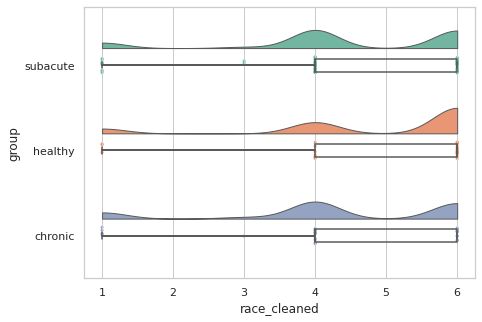

In [16]:
race_list = list(participants_df.race)
for i in range(0, len(race_list)):
    if "and" in race_list[i]:
        race_list[i] = int(race_list[i][0])
    else:
        race_list[i] = int(race_list[i])

participants_df["race_cleaned"] = race_list
dx = "group"; dy = "race_cleaned"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

['F' 'M']


<AxesSubplot:xlabel='encoded_gender', ylabel='group'>

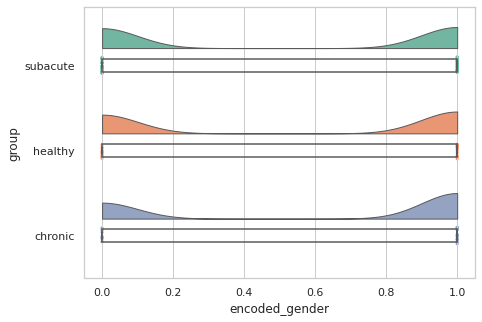

In [17]:
# for gender we will need to encode the labels
# male -> 1
# female -> 0
le = LabelEncoder()
le.fit(participants_df.gender)
print(le.classes_)
encoded_gender = le.transform(participants_df.gender)
participants_df["encoded_gender"] = encoded_gender

dx = "group"; dy = "encoded_gender"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

<AxesSubplot:xlabel='age', ylabel='group'>

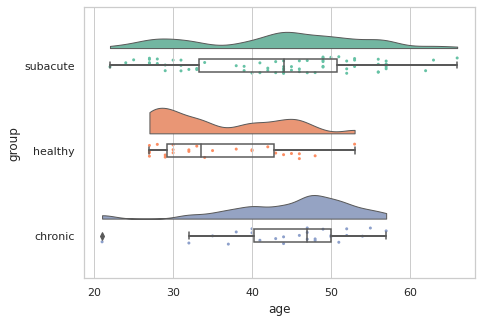

In [18]:
dx = "group"; dy = "age"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

<AxesSubplot:xlabel='years_education', ylabel='group'>

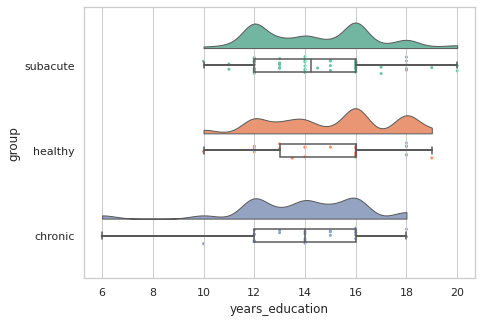

In [19]:
dx = "group"; dy = "years_education"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

<AxesSubplot:xlabel='$bracket', ylabel='group'>

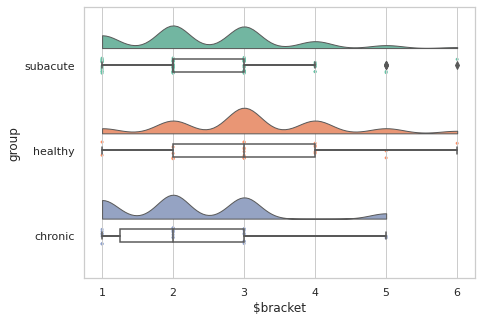

In [20]:
dx = "group"; dy = "$bracket"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

<AxesSubplot:xlabel='origin_cleaned', ylabel='group'>

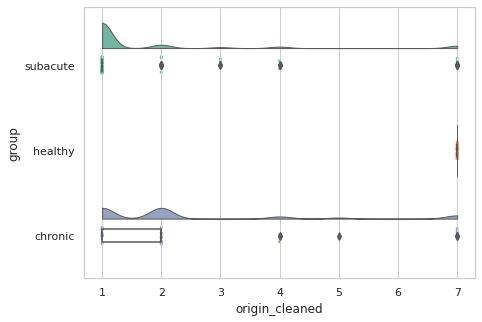

In [21]:
# here we need to replace nan values in origin column with 7 (which indicates Other)
participants_df["origin"] = participants_df["origin"].replace(np.nan, 7)
origin_list = list(participants_df.origin)
for i in range(0, len(origin_list)):
    if origin_list[i] == "1 and 3":
        origin_list[i] = int(origin_list[i][0])
    else:
        origin_list[i] = int(origin_list[i])

participants_df["origin_cleaned"] = origin_list

dx = "group"; dy = "origin_cleaned"; ort = "h"; pal = "Set2"; sigma = .1
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

<AxesSubplot:xlabel='origin_cleaned', ylabel='group'>

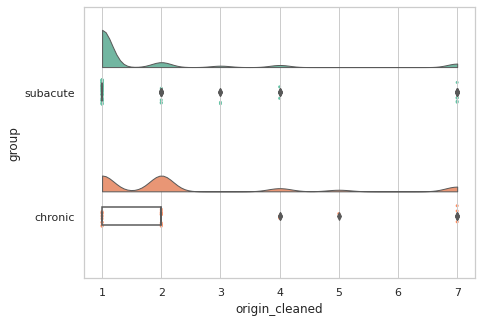

In [22]:
index_names = participants_df[participants_df['group'] == "healthy"].index
unhealthy_participants_df = participants_df.drop(index_names, inplace = False)
dx = "group"; dy = "origin_cleaned"; ort = "h"; pal = "Set2"; sigma = .1
f, ax = plt.subplots(figsize=(7, 5))
pt.RainCloud(x = dx, y = dy, data = unhealthy_participants_df, palette = pal, bw = sigma, width_viol = .6, ax = ax, orient = ort)

We can conclude most people with subacute back pain got it Spontaneously (just happened), while those with chronic pain have it due to some injury.

## 1.5 Basic analysis of fmri data

Websites used:
1. https://nilearn.github.io/stable/decoding/index.html (not used)
2. https://nistats.github.io/introduction.html
3. https://brainhack101.github.io/introML-book/01/MAIN_tutorial_intro_to_nilearn.html (intro to nilearn and ml with nilearn)

This analysis is just on subject 1, session 1.

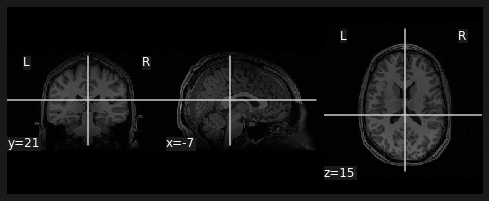

In [23]:
nplot.plot_anat("openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/anat/sub-001_ses-visit1_T1w.nii.gz")

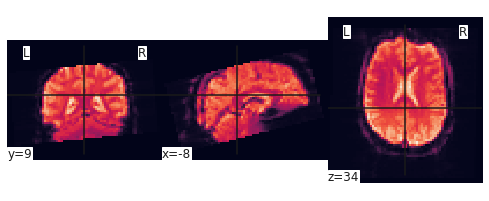

In [24]:
nplot.plot_img(nimg.mean_img("openpain.org/subacute_longitudinal_study/sub-001/ses-visit1/func/sub-001_ses-visit1_task-mv_bold.nii.gz"))

## error logs:
Uh-oh, what happened ?! Let’s look back at the error message:

Solved using: https://brainhack101.github.io/introML-book/01/MAIN_tutorial_intro_to_nilearn.html

    DimensionError: Input data has incompatible dimensionality: Expected dimension is 3D and you provided a 4D image. See http://nilearn.github.io/manipulating_images/input_output.html.

We can fix that ! Let’s take an average of the EPI image and plot that instead:

```python
from nilearn.image import mean_img
plotting.view_img(mean_img(os.path.join(data_dir, fmri_filename)))
```

## Doubt:
How do we deal with all this missing data in the session files?

In [25]:
read_json("openpain.org/subacute_longitudinal_study/sessions.json")

{
 "smoker": {
  "LongName": "Smoker",
  "Description": "Does the subject self report smoking cigarettes",
  "Levels": {
   "y": "Yes, subject reports smoking cigarettes",
   "n": "No, subject does not smoke cigarettes"
  }
 },
 "hours_sleep": {
  "LongName": "Hours of sleep per night",
  "Description": "How many hours the subject self reports sleeping on a typical night",
  "Units": "hours/night"
 },
 "limited_self_care/mobility": {
  "LongName": "Limited in self care or mobility",
  "Description": "Does subject report they are limited in any self-care or mobility?",
  "Levels": {
   "y": "Yes",
   "n": "No"
  },
  "bdi_total": {
   "LongName": "Beck's Depression Inventory 1A",
   "Description": "Total score on Beck's Depression Inventory, a 21 question survey, that scores severity of depressive symptoms. Weighted scores are added to produce a final score"
  },
  "panas_positive_affect": {
   "LongName": "Positive affect component of positive and negative affectivity Scale",
   "Descr

In [26]:
session_sub_1 = pd.read_csv("openpain.org/subacute_longitudinal_study/sub-001/sub-001_sessions.tsv", sep='\t')
session_sub_1

,session_id,days_since_interview,hours_sleep,smoker,limited_self_care/mobility,bdi_total,panas_positive_affect,panas_negative_affect,sf-12_q1,sf-12_q2a,...,mpq_vas,medications,nps_total,pdi_total,pdetect_pain_now,pdetect_strongest_4wks,pdetect_pain_average_4wks,pdetect_pain_course,pdetect_total,changes_since_last_visit
0,interview,0.0,6 to 7,n,y,1.0,31,12,2,2,...,0.376238,NaN,22,2,NaN,NaN,NaN,NaN,NaN,NaN
1,visit1,4.0,6 to 7,n,n,NaN,25,21,3,2,...,0.383838,None,34,17,NaN,NaN,NaN,NaN,NaN,injury/more pain
2,visit2,94.0,NaN,NaN,NaN,NaN,21,26,4,1,...,0.473684,None,42,21,NaN,NaN,NaN,NaN,NaN,more/different pain
3,visit3,NaN,7,n,n,7.0,25,27,2,3,...,0.153061,NaN,18,2,NaN,NaN,NaN,NaN,NaN,none
4,visit4,395.0,NaN,NaN,NaN,7.0,25,27,2,3,...,0.152284,NaN,18,2,NaN,NaN,NaN,NaN,NaN,NaN
5,visit5,1183.0,7,n,n,0.0,30,14,2,3,...,0.000000,no medications,0,0,0.0,0.0,0.0,0.0,0.0,pain no longer present


In [27]:
def drop_na_cols(df):
    df_na_dropped = df.dropna(axis = 1)
    df_na_dropped_cols = list(df_na_dropped.columns)
    print(df_na_dropped_cols, len(df_na_dropped_cols))
    return len(df_na_dropped_cols), df_na_dropped_cols

drop_na_cols(session_sub_1)

['session_id', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total'] 33


(33,
 ['session_id',
  'panas_positive_affect',
  'panas_negative_affect',
  'sf-12_q1',
  'sf-12_q2a',
  'sf-12_q2b',
  'sf-12_q3a',
  'sf-12_q3b',
  'sf-12_q4a',
  'sf-12_q4b',
  'sf-12_q5 ',
  'sf-12_q6a ',
  'sf-12_q6b',
  'sf-12_q6c',
  'sf-12_q7',
  'mpq_sensory',
  'mpq_affective',
  'r1',
  'r2',
  'r3',
  'r4',
  'r5',
  'r6',
  'r7',
  'r8',
  'r9',
  'r10',
  'r11',
  'r12',
  'mpq_radiculopathy',
  'mpq_vas',
  'nps_total',
  'pdi_total'])

In [28]:
session_sub_104 = pd.read_csv("openpain.org/subacute_longitudinal_study/sub-104/sub-104_sessions.tsv", sep='\t')
drop_na_cols(session_sub_104)

['session_id'] 1


(1, ['session_id'])

## 1.6 Dealing with missing session data

Since we can see this disparity in the amount of data that is missing we probably need to look at all the files and summarise which parts of the dataset to start to use.

In [29]:
layout_df = layout.to_df()

In [30]:
print(layout_df.path[100], layout_df.subject[100])

/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-003/ses-visit4/func/sub-003_ses-visit4_task-mv_bold.nii.gz 003


In [31]:
layout_dropped_na_subjects = layout_df[layout_df["subject"].notna()]
layout_dropped_na_subjects_tsv = layout_dropped_na_subjects[layout_dropped_na_subjects["extension"] == ".tsv"]
layout_dropped_na_subjects_tsv

entity,path,datatype,extension,run,session,subject,suffix,task
38,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,001,sessions,NaN
71,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,002,sessions,NaN
110,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,003,sessions,NaN
146,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,004,sessions,NaN
180,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,005,sessions,NaN
...,...,...,...,...,...,...,...,...
3948,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,118,sessions,NaN
3984,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,119,sessions,NaN
4021,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,120,sessions,NaN
4050,/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/...,NaN,.tsv,NaN,NaN,121,sessions,NaN


In [32]:
number_of_columns = []
for index, row in layout_dropped_na_subjects_tsv.iterrows():
    # print(row["path"])
    df = pd.read_csv(row["path"], sep="\t")
    number_of_columns.append(drop_na_cols(df)[0])

['session_id', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total'] 33
['session_id', 'days_since_interview', 'mpq_vas'] 3
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total'] 34
['session_id', 'days_since_interview', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'm

['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 19
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 38
['session_id', 'days_since_interview', 'smoker', 'limited_self_care/mobility', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12

['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'mpq_sensory', 'mpq_affective', 'mpq_vas', 'nps_total', 'pdetect_total'] 9
['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'medications', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_total'] 40
['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf

['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview'] 2
['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'panas_positive_affect', 'panas_negative_affect'] 7
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview'] 2
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect'] 4
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q

['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'medications', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 41
['session_id'] 1
['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas'] 21
['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', '

In [33]:
print(sorted(number_of_columns, reverse=True))
print(stats.mode(number_of_columns))

[44, 43, 43, 43, 43, 42, 42, 41, 41, 41, 41, 41, 40, 40, 40, 40, 40, 40, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 38, 38, 38, 38, 38, 38, 38, 38, 38, 37, 37, 37, 37, 36, 36, 36, 35, 35, 35, 35, 34, 34, 34, 33, 33, 33, 33, 33, 33, 32, 32, 31, 29, 28, 28, 27, 27, 26, 25, 24, 22, 21, 21, 21, 21, 20, 20, 19, 19, 18, 18, 18, 18, 18, 17, 17, 16, 16, 16, 16, 16, 16, 15, 9, 7, 5, 5, 4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
ModeResult(mode=array([39]), count=array([12]))


So we are going to analyze those patients with the 33 columns or more present. Now we need to decide the way these columns are choosen.
```
Logic:
all_col_names # 2d list of list of strings
 if len(cols) > 33:
     add the columns names to all_col_names
in all_col_names we need to find an intersection between all the lists.
```

In [34]:
list_of_list_of_cols = []
subjects = []
for index, row in layout_dropped_na_subjects_tsv.iterrows():
    # print(row["path"])
    df = pd.read_csv(row["path"], sep="\t")
    number_of_columns, columns = drop_na_cols(df)
    if number_of_columns > 33:
        subjects.append(row["subject"])
        list_of_list_of_cols.append(columns)

['session_id', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total'] 33
['session_id', 'days_since_interview', 'mpq_vas'] 3
['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total'] 34
['session_id', 'days_since_interview', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'm

['session_id', 'days_since_interview', 'panas_positive_affect', 'panas_negative_affect', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 27
['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 42
['session_id', 'days_since_interview', 'pana

['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'medications', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_total'] 28
['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'mpq_sensory', 'mpq_affective', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'mpq_radiculopathy', 'mpq_vas', 'nps_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_total'] 38
['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'bdi_total', 'panas_pos

['session_id', 'days_since_interview', 'hours_sleep', 'smoker', 'limited_self_care/mobility', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7'] 20
['session_id'] 1
['session_id'] 1
['session_id'] 1
['session_id'] 1
['session_id', 'days_since_interview', 'bdi_total', 'panas_positive_affect', 'panas_negative_affect', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7'] 17
['session_id', 'days_since_interview', 'sf-12_q1', 'sf-12_q2a', 'sf-12_q2b', 'sf-12_q3a', 'sf-12_q3b', 'sf-12_q4a', 'sf-12_q4b', 'sf-12_q5 ', 'sf-12_q6a ', 'sf-12_q6b', 'sf-12_q6c', 'sf-12_q7', 'nps_total', 'pdi_total', 'pdetect_pain_now ', 'pdetect_strongest_4wks', 'pdetect_pain_average_4wks', 'pdetect_pain_course', 'pdetect_total'] 21
['session_id', 'da

In [35]:
cols_to_take = set.intersection(*map(set,list_of_list_of_cols))
print(cols_to_take, len(cols_to_take))

{'r5', 'r9', 'r8', 'r1', 'session_id', 'r7', 'days_since_interview', 'r6', 'r12', 'r11', 'sf-12_q6a ', 'r4', 'r3'} 13


In [36]:
print(subjects)

['003', '007', '010', '016', '017', '018', '019', '021', '023', '025', '028', '029', '030', '032', '033', '034', '038', '039', '041', '043', '044', '046', '047', '050', '052', '053', '055', '056', '058', '059', '060', '061', '062', '063', '065', '066', '067', '068', '069', '098', '100', '102', '106', '107', '109', '111', '112', '113', '116', '117', '118', '120', '121']


In [37]:
prefixed_subjects = ['sub-' + subject for subject in subjects]

In [38]:
# see these subjects
selected_partcipants = participants_df[participants_df['participant_id'].isin(prefixed_subjects)]
selected_partcipants

,participant_id,group,race,gender,age,years_education,$bracket,approximate_duration_in_weeks,origin,rs2239393,...,rs678849,rs6090453,rs4334545,rs324419,rs2295633,rs6265,rs16147,race_cleaned,encoded_gender,origin_cleaned
2,sub-003,subacute,4,F,49,12.0,3.0,4.0,1,AA,...,CC,CC,CT,CC,GG,CC,CT,4,0,1
6,sub-007,subacute,6,F,43,12.0,4.0,21.0,2,AA,...,CT,CG,CT,CC,GG,CC,CC,6,0,2
9,sub-010,subacute,4,F,44,12.0,2.0,18.0,1,GG,...,CT,CC,CC,CT,AA,CC,TT,4,0,1
15,sub-016,subacute,3,M,29,19.0,4.0,8.0,1,AA,...,CT,CG,CC,CC,GG,CT,CT,3,1,1
16,sub-017,subacute,6,F,62,18.0,NaN,5.0,1,AG,...,TT,CC,CC,CC,GG,CC,CC,6,0,1
17,sub-018,subacute,6,M,42,20.0,5.0,12.0,2,GG,...,CC,GG,CC,CC,AG,CC,TT,6,1,2
18,sub-019,subacute,4,M,52,10.0,1.0,7.0,1,AG,...,CT,CG,CC,CC,GG,CC,CT,4,1,1
20,sub-021,subacute,6,M,46,14.0,4.0,7.0,1,AA,...,CT,CG,CT,CC,AG,CC,TT,6,1,1
22,sub-023,subacute,1,M,53,12.0,2.0,13.0,1,AA,...,CT,CG,CC,CC,AG,CT,TT,1,1,1
24,sub-025,subacute,4,F,31,12.0,1.0,4.0,1,AA,...,CC,CC,CT,CC,AG,CC,TT,4,0,1


In [39]:
i = 0
for index, row in layout_dropped_na_subjects_tsv.iterrows():
    if i < 1:
        break
    df = pd.read_csv(row["path"], sep="\t")
    i += 1

In [40]:
df['mpq_vas']

0    0.6903553299
1    0.6326530612
2         add vas
3             NaN
4    0.6923076923
Name: mpq_vas, dtype: object

In [41]:
df['nps_total']

0    31.0
1     NaN
2    31.0
3     NaN
4    35.0
Name: nps_total, dtype: float64

  "mpq_vas": {
   "LongName": "Visual analog scale score",
   "Description": "Subjects designate their overall pain level by marking a point on a continuous line anchored by 'No Pain' and 'Worst Possible Pain' at each end. Distance from the end of the line is measured and score is assigned based on fraction of total line length demarcated by subjects self report. Score ranges from 0-1"
  },
  "medications": {
   "LongName": "Subject's reported medication regimen",
   "Description": "Subject's self report of medication usage. Unless otherwise indicated any medication indicated was taken on an as needed basis (PRN)"
  },
  "nps_total": {
   "LongName": "Neuropathy Pain Scale total score",
   "Description": "University of Washington Neuropathy Pain Scale measures sharpness, heat/cold, dullness, intensity, overall unpleasantness and surface vs. deep pain using 9 questions each scored between 0 (low severity) or 10 (high severity). The answer to a 10th question on this questioniare is qualitative and does not factor into this score.",
   "TermURL": "https://www.ncbi.nlm.nih.gov/pubmed/9040716"
  },
  "pdi_total": {
   "LongName": "Pain disability index total score",
   "Description": "A questionaire that asks patients to report how much pain interferes with severn areas of life activity: family/home, recreation, social, occupation, sexual, self-care, life-support and on average. Higher scores indicate more severe disability. Possible scores range from 0-70"
  },
  "pdetect_pain_now": {
   "LongName": "Pain right now",
   "Description": "How would you assess your pain NOW, at this moment? Scores from 0-10, anchored by 'none' and 'max'"
  },

## 1.7 Looking at functional data

Follwed this guide: https://carpentries-incubator.github.io/SDC-BIDS-fMRI/04-integrating_functional_data/index.html

https://github.com/bids-standard/pybids/blob/0.14.0/examples/pybids_tutorial.ipynb

In [42]:
func_files = layout.get(subject="002",
                        datatype="func",
                        extension="nii.gz",
                        task="sp",
                        run=2,
                        return_type="file",
                        session="visit1"
                       )
resp_files = ["/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-002/ses-visit1/func/sub-002_ses-visit1_task-sp_run-02_resp.tsv.gz"]

In [43]:
print(func_files, resp_files)

['/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-002/ses-visit1/func/sub-002_ses-visit1_task-sp_run-02_bold.nii.gz'] ['/rds/project/rds-3IOyKgCQu4I/sbp/openpain.org/subacute_longitudinal_study/sub-002/ses-visit1/func/sub-002_ses-visit1_task-sp_run-02_resp.tsv.gz']


In [44]:
print(layout.get_entities(func_files[0]), layout.get_entities(resp_files[0]))

{} {}


In [45]:
func_mni = func_files[0]
resp_mni = resp_files[0]
func_mni_img = nimg.load_img(func_mni)

In [46]:
func_mni_img.shape

(64, 64, 36, 244)


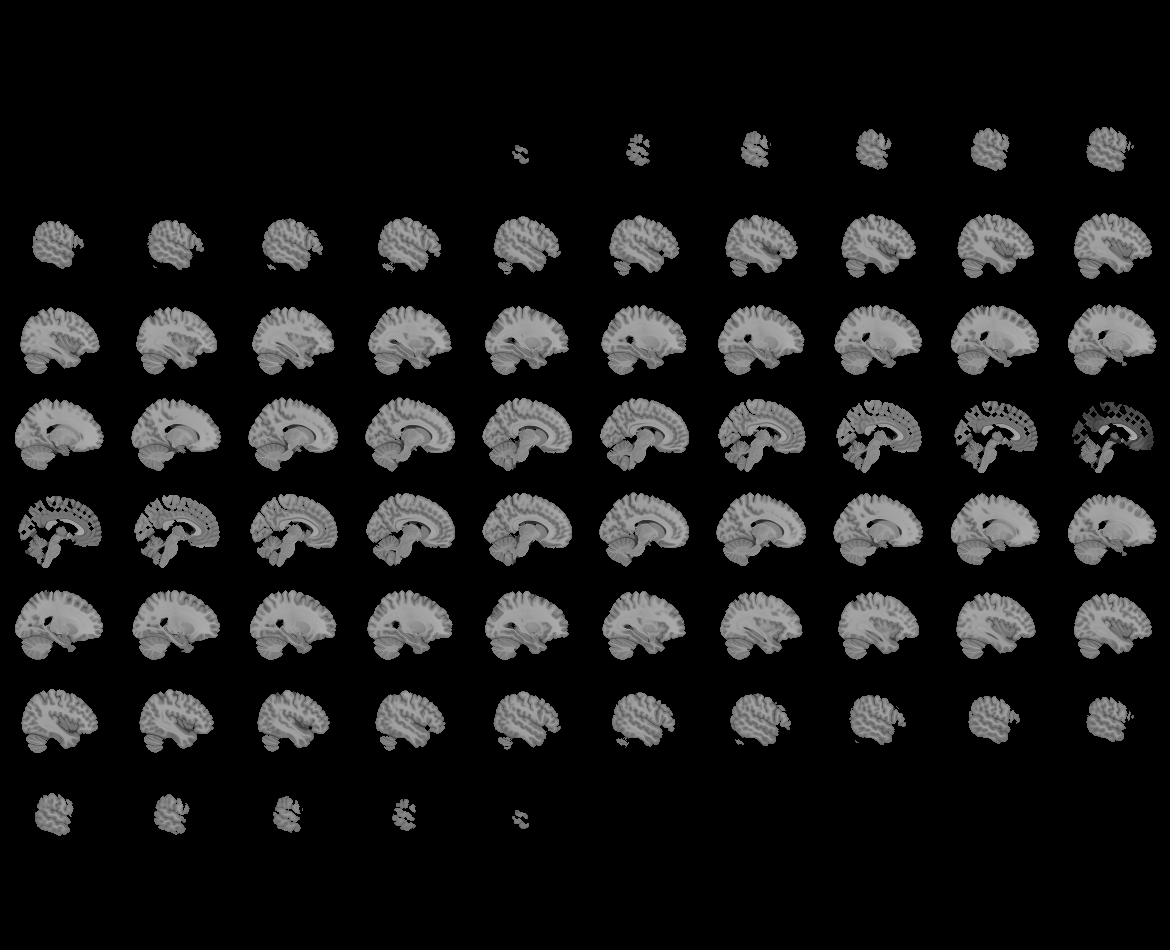
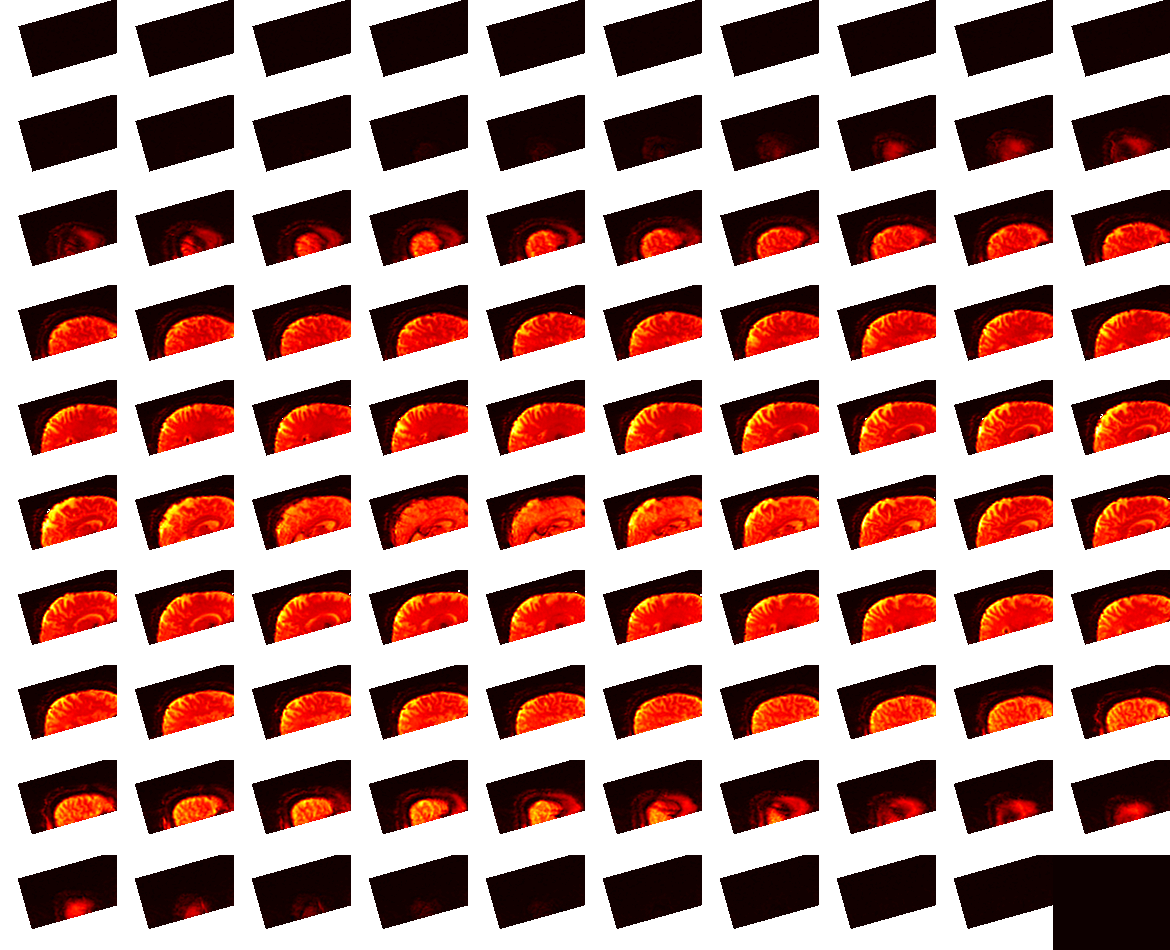

In [47]:
func_vol7 = func_mni_img.slicer[:,:,:,6]
nplot.view_img(func_vol7)

In [48]:
#Pick one voxel at coordinate (60,45,88)
single_vox = func_mni_img.slicer[59:60,45:46,30:31,:].get_data()
print(single_vox.shape)
single_vox = single_vox.flatten()
print(single_vox.shape)

(1, 1, 1, 244)
(244,)


Text(0, 0.5, 'Signal Value')

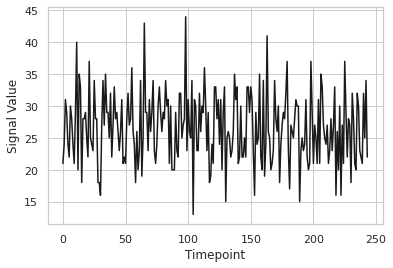

In [49]:
# Make an array counting from 0 --> 152, this will be our x-axis
x_axis = np.arange(0, single_vox.shape[0])

# Plot our x and y data, the 'k' just specifies the line color to be black
plt.plot(x_axis, single_vox, 'k')

# Label our axes
plt.xlabel('Timepoint')
plt.ylabel('Signal Value')

In [50]:
f = gzip.open(resp_mni, 'rb')
response_sp_100 = f.read().decode("utf-8").split("\n")
to_delete = []
for i in range(0, len(response_sp_100)):
    try:
        response_sp_100[i] = float(response_sp_100[i])
    except:
        to_delete.append(i)

for i in to_delete:
    del response_sp_100[i]
print(len(response_sp_100))

8784


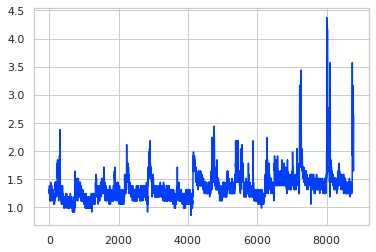

In [51]:
plt.plot(response_sp_100)

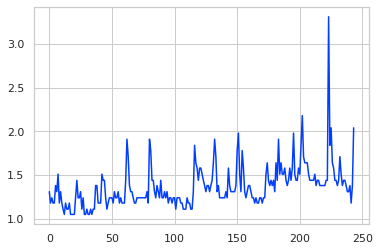

In [52]:
plt.plot(response_sp_100[::36])

## 1.8 Single file Analysis

https://nistats.github.io/auto_examples/01_tutorials/plot_single_subject_single_run.html

## 1.9 Tasks

task-sp_bold.json

```
"EchoTime": 0.03,
 "SliceTiming": [1255, 0, 1322.5, 70, 1392.5, 137.5, 1462.5, 207.5, 1532.5, 277.5, 1602.5, 347.5, 1672.5, 417.5, 1742.5, 487.5, 1812.5, 557.5, 1882.5, 627.5, 1950, 695, 2020, 765, 2090, 835, 2160, 905, 2230, 975, 2300, 1045, 2370, 1115, 2440, 1185],
 "FlipAngle": 80,
 "Instructions": "During this scan please rate your pain using the finger device o na scale from 0 to 100, where 0 is no pain and 100 is the worst pain imaginable. On the screen in front of you you will see a yellow bar which will move with your fingers reflecting your current rating. Please use this to record your pain, including any moment by moment fluctuations."/
```

task-mv_bold.json

```
"EchoTime": 0.03,
"SliceTiming": [1255, 0, 1322.5, 70, 1392.5, 137.5, 1462.5, 207.5, 1532.5, 277.5, 1602.5, 347.5, 1672.5, 417.5, 1742.5, 487.5, 1812.5, 557.5, 1882.5, 627.5, 1950, 695, 2020, 765, 2090, 835, 2160, 905, 2230, 975, 2300, 1045, 2370, 1115, 2440, 1185],
"FlipAngle": 80,
"Instructions": "During this scan you will see a yellow bar on the screen in front of you. The bar will move on your own and will not reflect your finger movements, but please try to use the finger device to track the movement of the bar as closely as you can.",
 "TaskDescription": "The yellow bar is controlled by a stimulus vector which is matched to one of the subjects own prior pain rating runs, so this serves as a visuomotor control for their pain rating task but will differ from one subject to the next to the extent to which their pain rating reports differred."
```

task-sv_bold.json

```
"EchoTime": 0.03,
"SliceTiming": [1255, 0, 1322.5, 70, 1392.5, 137.5, 1462.5, 207.5, 1532.5, 277.5, 1602.5, 347.5, 1672.5, 417.5, 1742.5, 487.5, 1812.5, 557.5, 1882.5, 627.5, 1950, 695, 2020, 765, 2090, 835, 2160, 905, 2230, 975, 2300, 1045, 2370, 1115, 2440, 1185],
"FlipAngle": 80,
"Instructions": "During this scan you will see a yellow bar on the screen in front of you. The bar will move on your own and will not reflect your finger movements, but please try to use the finger device to track the movement of the bar as closely as you can.",
"TaskDescription": "The yellow bar is controlled by a predefined sequence, and serves as a visuomotor control for the pain rating task. Although there may be differences between a subjects precise finger motions and visual perception during their pain rating tasks and during this task, this provides a common visuomotor control across all subjects since they will all experience the same visual stimulus during this task."
```